In [1]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from joblib import Parallel, delayed
from datatools import *
import matplotlib.pyplot as plt
import seaborn as sns

### 策略

In [ ]:
all_sample = pd.read_parquet('C:/Users/User/OneDrive - CUHK-Shenzhen/data/factor/all_sample.parquet')

In [ ]:
start_date = '2019-01-01'
end_date = '2026-04-30'
allstocks = pd.read_csv('C:/Users/User/OneDrive - CUHK-Shenzhen/data/allstock.csv')
allstocks = allstocks[~allstocks['ts_code'].str.contains('BJ')].ts_code.tolist()
load_start = (pd.Timestamp(start_date) - pd.DateOffset(years=1)).strftime('%Y-%m-%d')
price = get_price(codes=allstocks, start_date=load_start, end_date=end_date).rename(columns={'open':'next_open'})
price['daily_return'] = price['close']/price['pre_close'] - 1
price['next_open'] = price.groupby('ts_code')['next_open'].shift(-1)
price = price.sort_values(by=['ts_code', 'trade_date']).reset_index(drop=True)

### rsrs

In [ ]:
# ── 构建矩阵 ──────────────────────────────────────────────────────────────
dates = np.sort(price['trade_date'].unique())
universe = np.sort(price['ts_code'].unique())

high_pivot = price.pivot(index='trade_date', columns='ts_code', values='high').reindex(index=dates, columns=universe)
low_pivot = price.pivot(index='trade_date', columns='ts_code', values='low').reindex(index=dates, columns=universe)

n_dates, n_stocks = len(dates), len(universe)
print(f'矩阵: {n_dates} 交易日 × {n_stocks} 只股票')
N=18
M=600
cov_xy = high_pivot.rolling(N, min_periods=2).cov(low_pivot)
var_x = low_pivot.rolling(N, min_periods=2).var()
var_y = high_pivot.rolling(N, min_periods=2).var()
slope = cov_xy / var_x
r2 = (cov_xy ** 2) / (var_x * var_y)
slope_zscore = (slope - slope.rolling(M, min_periods=2).mean()) / slope.rolling(M, min_periods=2).std()
rsrs = slope*r2*slope_zscore
rsrs = rsrs.loc[start_date:end_date]
rsrs = rsrs.stack().reset_index().rename(columns={0:'rsrs'})

矩阵: 4955 交易日 × 5489 只股票


### 最低点策略

In [ ]:
price['min_close'] = price.groupby('ts_code')['close'].rolling(window=185, min_periods=185).min().reset_index(level=0, drop=True)
price['signal'] = price['close'] == price['min_close']
price['sell_price'] = price.groupby('ts_code')['next_open'].shift(-38)
price['sell_date'] = price.groupby('ts_code')['trade_date'].shift(-38)
trade_records = price[(price['signal'] == 1)&(price['sell_price'].notna())]
trade_records['return_rate'] = trade_records['sell_price'] / trade_records['next_open'] - 1
trade_records = trade_records[['ts_code', 'trade_date', 'next_open', 'sell_date', 'sell_price', 'return_rate']]

# 1. 提取所有交易日并排序，作为净值曲线的基准
all_dates = pd.DataFrame(price['trade_date'].sort_values().unique(), columns=['trade_date'])
# 3. 将行情数据与交易记录合并，提取每笔交易持仓期间的每日收益
holding_df = price[['ts_code', 'trade_date', 'daily_return']].merge(trade_records[['ts_code', 'trade_date', 'sell_date']], 
                      on='ts_code',  suffixes=('', '_signal'))
# 筛选实际的持仓区间：产生信号次日之后，到卖出日之前
holding_df = holding_df[(holding_df['trade_date'] > holding_df['trade_date_signal']) & 
                        (holding_df['trade_date'] <= holding_df['sell_date'])]
# 4. 按交易日分组，计算当日所有持仓股票的等权日收益率
daily_strategy_ret = holding_df.groupby('trade_date')['daily_return'].mean().reset_index()
net_value_df = all_dates.merge(daily_strategy_ret, on='trade_date', how='left')
net_value_df = net_value_df[net_value_df['daily_return'].notna()]
# 6. 均摊扣除原代码中的单次交易成本0.003（持仓期固定为38天）
net_value_df['daily_return'] -= 0.003 / 38

metric = strategy_metrics(net_value_df,'000300.SH' , trade_records.rename(columns={'trade_date':'buy_date', 'next_open':'buy_price'}))

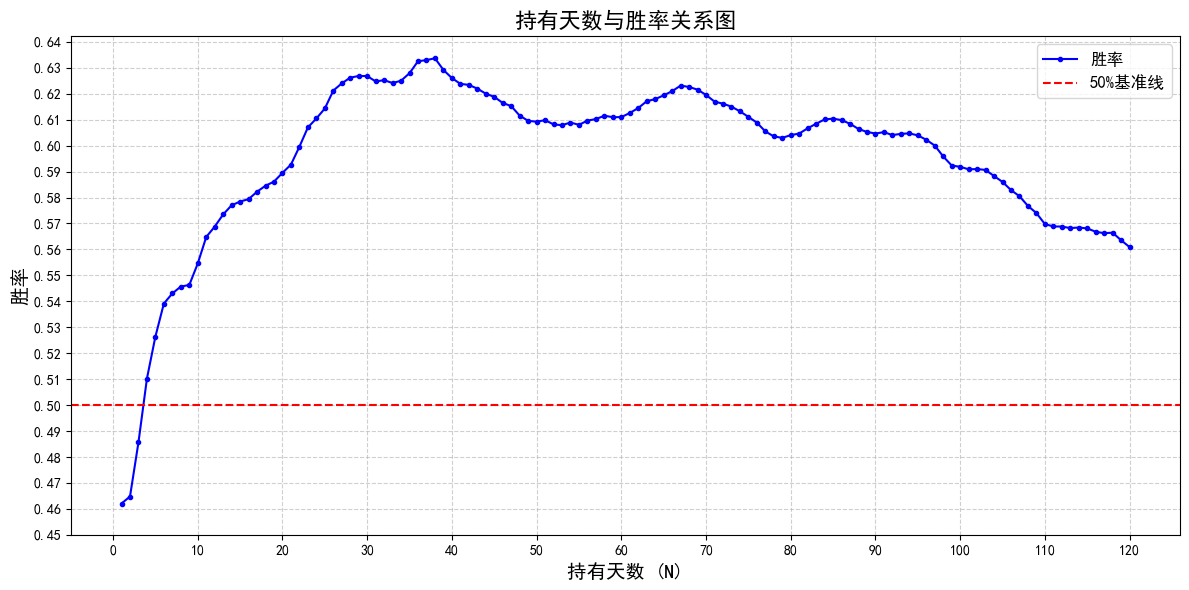

In [37]:
price['min_close'] = price.groupby('ts_code')['close'].rolling(window=185, min_periods=185).min().reset_index(level=0, drop=True)
price['signal'] = price['close'] == price['min_close']
holding_days_list = []
win_rates_list = []
# 3. 遍历 1 到 max_days 天，计算不同持有期下的胜率
for n in range(1, 120 + 1):
    price['sell_price'] = price.groupby('ts_code')['next_open'].shift(-n)
    price['sell_date'] = price.groupby('ts_code')['trade_date'].shift(-n)
    trade_records = price[(price['signal'] == 1)&(price['sell_price'].notna())]
    # 计算该笔交易是否盈利（卖出价 > 买入价）
    win_rate = (trade_records['sell_price']>trade_records['next_open']).sum() / len(trade_records)
    holding_days_list.append(n)
    win_rates_list.append(win_rate)
# 返回计算结果的数据框，便于查看具体数值
result_price = pd.DataFrame({'holding_days': holding_days_list, 'win_rate': win_rates_list})
# 4. 绘制折线图
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False
plt.figure(figsize=(12, 6))
plt.plot(holding_days_list, win_rates_list, marker='o', markersize=3, linestyle='-', color='b', label='胜率')
# 添加50%基准线，便于判断盈亏优势
plt.axhline(y=0.5, color='r', linestyle='--', label='50%基准线')
plt.title('持有天数与胜率关系图', fontsize=16)
plt.xlabel('持有天数 (N)', fontsize=14)
plt.ylabel('胜率', fontsize=14)
plt.xticks(np.arange(0, 120 + 1, 10))
plt.yticks(np.arange(0.45, 0.65, 0.01))
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()